# Level 1 — Task 2: Customer Segmentation Analysis

**Objective:** Cluster e-commerce customers on purchasing behaviour (RFM) so marketing can treat each group differently.

**Tech stack:** Python, pandas, scikit-learn (KMeans), matplotlib, seaborn

## 1. Data prep

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
DATA = Path("..") / "data" / "raw" / "ecommerce_customers.csv"
raw = pd.read_csv(DATA, parse_dates=["InvoiceDate"])
print(raw.shape)
print(raw.dtypes)
print(raw.isnull().sum())
raw.head()


(4200, 8)
InvoiceNo                 str
InvoiceDate    datetime64[us]
CustomerID                str
Country                   str
StockCode                 str
Description               str
Quantity                int64
UnitPrice             float64
dtype: object
InvoiceNo      0
InvoiceDate    0
CustomerID     0
Country        0
StockCode      0
Description    0
Quantity       0
UnitPrice      0
dtype: int64


,InvoiceNo,InvoiceDate,CustomerID,Country,StockCode,Description,Quantity,UnitPrice
0,INV-0001-001,2025-05-20,C0001,United Kingdom,SKU-819,LED Bulb,2,6.77
1,INV-0001-002,2025-02-20,C0001,India,SKU-453,Coffee Beans 500g,5,3.46
2,INV-0002-001,2025-06-29,C0002,India,SKU-483,Backpack,3,12.08
3,INV-0002-002,2025-03-11,C0002,United Kingdom,SKU-497,Coffee Beans 500g,5,6.60
4,INV-0002-003,2025-08-17,C0002,India,SKU-193,Coffee Beans 500g,1,36.86


In [2]:
tx = raw.copy()
tx = tx.dropna(subset=["CustomerID", "InvoiceDate", "Quantity", "UnitPrice"])
tx = tx[(tx["Quantity"] > 0) & (tx["UnitPrice"] > 0)]
tx["LineTotal"] = tx["Quantity"] * tx["UnitPrice"]
print("Rows after cleaning:", len(tx), "| Customers:", tx["CustomerID"].nunique())


Rows after cleaning: 4200 | Customers: 600


**Observation:** Negative quantities/prices (returns) and missing customer IDs are removed so RFM reflects actual purchases.

## 2. Descriptive statistics — AOV, frequency, CLV proxy

In [3]:
snapshot = tx["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = tx.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("LineTotal", "sum"),
)
rfm["AvgPurchaseValue"] = tx.groupby("CustomerID")["LineTotal"].mean()
# Simple CLV proxy: historical monetary value (could extend with expected frequency)
rfm["CLV_proxy"] = rfm["Monetary"]
print("Average purchase value (mean of customer AOVs):", round(rfm["AvgPurchaseValue"].mean(), 2))
print("Average order frequency:", round(rfm["Frequency"].mean(), 2))
print("Average CLV proxy (lifetime spend):", round(rfm["CLV_proxy"].mean(), 2))
rfm.describe().T


Average purchase value (mean of customer AOVs): 113.51
Average order frequency: 7.0
Average CLV proxy (lifetime spend): 1151.63


,count,mean,std,min,25%,50%,75%,max
Recency,600.0,129.943333,91.605801,1.00,54.0000,112.000000,194.000000,411.000000
Frequency,600.0,7.000000,5.436536,1.00,3.0000,6.000000,9.000000,27.000000
Monetary,600.0,1151.625750,1753.041130,17.16,110.8000,622.470000,1235.350000,9789.370000
AvgPurchaseValue,600.0,113.507650,89.666029,8.58,40.0675,93.870486,156.131364,469.224167
CLV_proxy,600.0,1151.625750,1753.041130,17.16,110.8000,622.470000,1235.350000,9789.370000


## 3. Feature selection (RFM)

Recency, Frequency, and Monetary are the three behavioural features used for clustering. They capture *how recently*, *how often*, and *how much* a customer buys.

## 4. Standardize features

In [4]:
features = ["Recency", "Frequency", "Monetary"]
X = rfm[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=features, index=rfm.index).head()


,Recency,Frequency,Monetary
CustomerID,,,
C0001,1.027611,-0.920471,-0.639871
C0002,0.055246,-0.736376,-0.596904
C0003,-1.135627,-0.368188,-0.571653
C0004,-0.895268,1.288659,1.764244
C0005,-1.026373,0.000000,-0.069866


## 5. K-Means + Elbow method

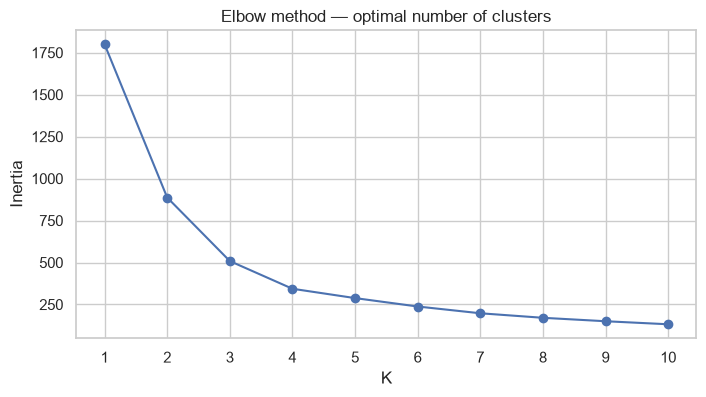

In [5]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.xticks(list(K_range))
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow method — optimal number of clusters")
plt.show()


**Observation:** The elbow typically appears around **K = 4**. That is a practical number of marketing segments (not so many that campaigns become unmanageable).

In [6]:
K = 4
model = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = model.fit_predict(X_scaled)
rfm["Cluster"].value_counts().sort_index()


Cluster
0    227
1     60
2    175
3    138
Name: count, dtype: int64

## 6. Visualizations

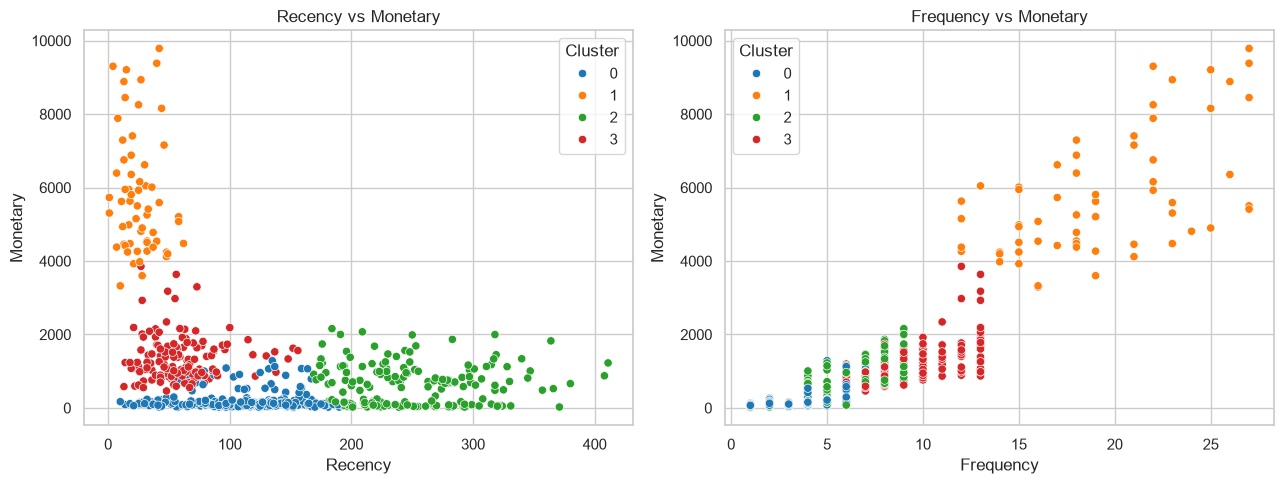

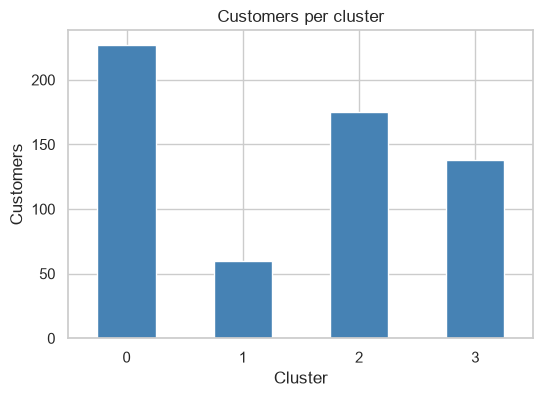

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette="tab10", ax=axes[0])
axes[0].set_title("Recency vs Monetary")
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette="tab10", ax=axes[1])
axes[1].set_title("Frequency vs Monetary")
plt.tight_layout()
plt.show()

counts = rfm["Cluster"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color="steelblue")
plt.title("Customers per cluster")
plt.xlabel("Cluster")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.show()


## 7. Cluster profiles

In [8]:
profile = rfm.groupby("Cluster")[features + ["AvgPurchaseValue"]].mean().round(2)
profile["Customers"] = rfm.groupby("Cluster").size()
profile


,Recency,Frequency,Monetary,AvgPurchaseValue,Customers
Cluster,,,,,
0,107.00,3.49,208.05,55.92,227
1,25.75,19.25,5820.84,308.00,60
2,250.91,4.96,628.11,106.85,175
3,59.59,10.04,1337.52,132.11,138


In [9]:
def label_cluster(row):
    if row["Recency"] <= profile["Recency"].median() and row["Monetary"] >= profile["Monetary"].median() and row["Frequency"] >= profile["Frequency"].median():
        return "Champions — recent, frequent, high spend"
    if row["Recency"] > profile["Recency"].median() and row["Monetary"] >= profile["Monetary"].quantile(0.4):
        return "At risk — used to spend, now quiet"
    if row["Frequency"] <= profile["Frequency"].quantile(0.4) and row["Recency"] <= profile["Recency"].median():
        return "New / promising — recent but few orders"
    return "Bargain / low-value — infrequent, smaller baskets"

labels = {}
for c, row in profile.iterrows():
    labels[c] = label_cluster(row)
profile["Persona"] = pd.Series(labels)
profile


,Recency,Frequency,Monetary,AvgPurchaseValue,Customers,Persona
Cluster,,,,,,
0,107.00,3.49,208.05,55.92,227,"Bargain / low-value — infrequent, smaller baskets"
1,25.75,19.25,5820.84,308.00,60,"Champions — recent, frequent, high spend"
2,250.91,4.96,628.11,106.85,175,"Bargain / low-value — infrequent, smaller baskets"
3,59.59,10.04,1337.52,132.11,138,"Champions — recent, frequent, high spend"


**Observation:** Each cluster maps to a customer type. High monetary + high frequency + low recency = champions. High recency (days since last buy) with decent past spend = at-risk. Low frequency + recent = new. Low monetary = bargain hunters.

## 8. Marketing actions per segment

Use the persona table above; typical actions:

| Segment | Action |
|---|---|
| Champions | Loyalty rewards, early access, referral asks |
| Loyal / core | Bundles and category expansion emails |
| At risk | Win-back coupon with expiry, “we miss you” |
| New | Onboarding series, first-repeat discount |
| Bargain | Value packs, free-shipping threshold — avoid deep discounts on premium SKUs |

## Conclusion

K-Means on standardized RFM produces distinct, usable segments. Marketing should stop treating the database as one list: champions get retention, at-risk get win-back, new customers get a second-order push, and low-value buyers get cost-efficient offers only.